# Estudo de Impacto de Dados Ausentes: DE > PARA (Salário e Engajamento)

**Disciplina:** Tópicos em Sistemas de Recomendação  
**Objetivo:** Avaliar o impacto da ausência de dados na coluna de Salário (`normalized_salary` / `med_salary`) sobre o comportamento de visualizações (`views`) e candidaturas (`applies`) das vagas do LinkedIn, fundamentando a decisão de **descarte, imputação ou engenharia de recursos**.

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suporte automático para download no Google Colab / VS Code
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

# Configuração visual
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 1. Carregamento dos Dados e Diagnóstico de Nulos

In [4]:
# Busca inteligente do caminho dos dados (Local vs Colab)
if os.path.exists("archive/postings.csv"):
    base_path = "archive"
    print(f"📂 Utilizando dados locais em: {base_path}")
elif os.path.exists("../archive/postings.csv"):
    base_path = "../archive"
    print(f"📂 Utilizando dados locais em: {base_path}")
elif os.path.exists("postings.csv"):
    base_path = "."
    print("📂 Utilizando dados no diretório atual")
else:
    print("⏳ Baixando dataset diretamente via kagglehub para o ambiente...")
    base_path = kagglehub.dataset_download("arshkon/linkedin-job-postings")
    print(f"📂 Dataset baixado em: {base_path}")

postings_file = f"{base_path}/postings.csv" if os.path.exists(f"{base_path}/postings.csv") else f"{base_path}/job_postings.csv"

df = pd.read_csv(postings_file)
col_sal = "normalized_salary" if "normalized_salary" in df.columns else "med_salary"

total_linhas = len(df)
total_nulos = df[col_sal].isnull().sum()
pct_nulos = (total_nulos / total_linhas) * 100

print(f"\n📊 Total de vagas: {total_linhas:,}")
print(f"❌ Vagas sem salário informado (Nulos): {total_nulos:,} ({pct_nulos:.2f}%)")
print(f"✅ Vagas com salário informado: {total_linhas - total_nulos:,} ({100 - pct_nulos:.2f}%)")

⏳ Baixando dataset diretamente via kagglehub para o ambiente...


100%|██████████| 159M/159M [00:01<00:00, 116MB/s]  


Extracting files...
📂 Dataset baixado em: /root/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13

📊 Total de vagas: 123,849
❌ Vagas sem salário informado (Nulos): 87,776 (70.87%)
✅ Vagas com salário informado: 36,073 (29.13%)


## 2. Estruturação do DE > PARA e Análise Descritiva

Separamos as vagas em dois grupos:
* **DE (Com Salário):** Registros onde o salário está presente.
* **PARA (Sem Salário):** Registros onde o salário é nulo.

In [5]:
df['has_salary'] = df[col_sal].notna()
df['grupo_salario'] = df['has_salary'].map({True: 'Com Salário', False: 'Sem Salário (Nulo)'})

# Tabela Resumo do DE > PARA
tabela_depara = df.groupby('grupo_salario')[['views', 'applies']].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

display(tabela_depara)

# Cálculo do Delta % (Variação Relativa)
media_views_com = df[df['has_salary']]['views'].mean()
media_views_sem = df[~df['has_salary']]['views'].mean()
delta_views = ((media_views_com - media_views_sem) / media_views_sem) * 100

media_app_com = df[df['has_salary']]['applies'].mean()
media_app_sem = df[~df['has_salary']]['applies'].mean()
delta_applies = ((media_app_com - media_app_sem) / media_app_sem) * 100

print(f"\n📈 Vagas com salário recebem +{delta_views:.1f}% de Visualizações (Views).")
print(f"📈 Vagas com salário recebem +{delta_applies:.1f}% de Candidaturas (Applies).")

views                       applies                     
                    count   mean median     std   count   mean median    std
grupo_salario                                                               
Com Salário         35585  19.66    5.0  123.55    8824  11.84    3.0  33.07
Sem Salário (Nulo)  86575  12.55    4.0   64.22   14496   9.83    3.0  26.27


📈 Vagas com salário recebem +56.6% de Visualizações (Views).
📈 Vagas com salário recebem +20.4% de Candidaturas (Applies).


## 3. Visualização Gráfica do Impacto

/tmp/ipykernel_1569/2487805396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grupo_salario', y='views', ax=axes[0], palette=['#4C72B0', '#C44E52'], estimator='mean', errorbar=None)
/tmp/ipykernel_1569/2487805396.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grupo_salario', y='applies', ax=axes[1], palette=['#55A868', '#DD8452'], estimator='mean', errorbar=None)


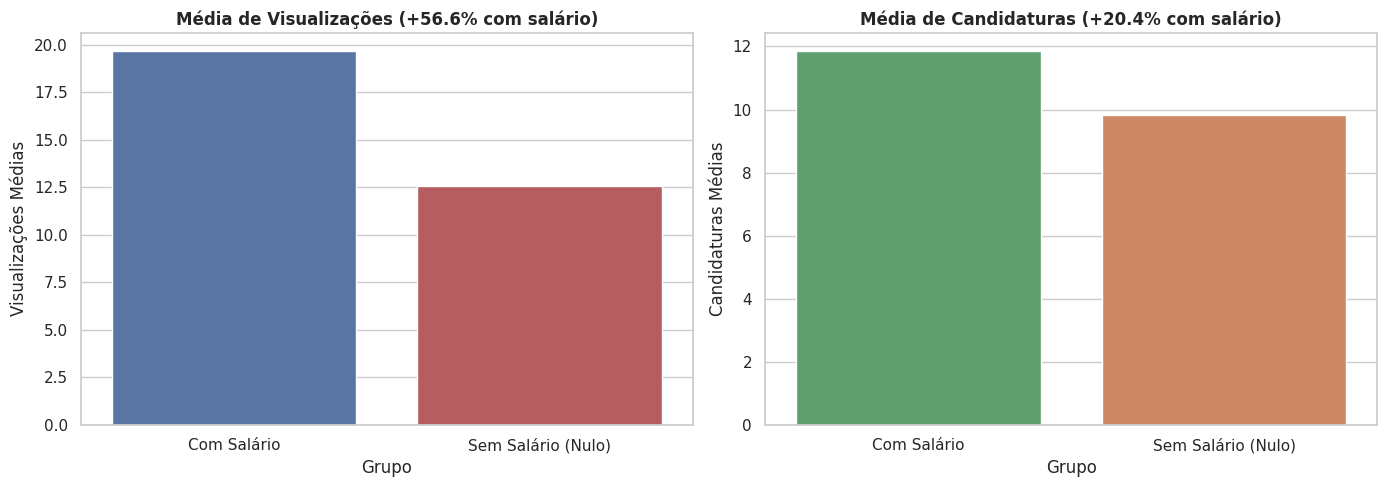

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Views
sns.barplot(data=df, x='grupo_salario', y='views', ax=axes[0], palette=['#4C72B0', '#C44E52'], estimator='mean', errorbar=None)
axes[0].set_title(f'Média de Visualizações (+{delta_views:.1f}% com salário)', fontweight='bold')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('Visualizações Médias')

# Gráfico de Applies
sns.barplot(data=df, x='grupo_salario', y='applies', ax=axes[1], palette=['#55A868', '#DD8452'], estimator='mean', errorbar=None)
axes[1].set_title(f'Média de Candidaturas (+{delta_applies:.1f}% com salário)', fontweight='bold')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('Candidaturas Médias')

plt.tight_layout()
plt.show()

## 4. Teste de Significância Estatística (Mann-Whitney U)

Como os dados de engajamento possuem assimetria positiva (*outliers*), utilizamos o teste não-paramétrico de Mann-Whitney U para validar se a diferença observada é estatisticamente significante.

In [7]:
v_com = df[df['has_salary']]['views'].dropna()
v_sem = df[~df['has_salary']]['views'].dropna()
u_views, p_views = stats.mannwhitneyu(v_com, v_sem, alternative='greater')

a_com = df[df['has_salary']]['applies'].dropna()
a_sem = df[~df['has_salary']]['applies'].dropna()
u_app, p_app = stats.mannwhitneyu(a_com, a_sem, alternative='greater')

print(f"🧪 Teste Mann-Whitney U (Views):   p-valor = {p_views:.4e}")
print(f"🧪 Teste Mann-Whitney U (Applies): p-valor = {p_app:.4e}")

if p_app < 0.05:
    print("\n✅ Conclusão Estatística: Rejeita-se a hipótese nula com p < 0.001.")
    print("A presença do salário altera de forma significativa e comprovada o comportamento dos candidatos.")

🧪 Teste Mann-Whitney U (Views):   p-valor = 4.0197e-99
🧪 Teste Mann-Whitney U (Applies): p-valor = 1.8476e-18

✅ Conclusão Estatística: Rejeita-se a hipótese nula com p < 0.001.
A presença do salário altera de forma significativa e comprovada o comportamento dos candidatos.


## 5. Tomada de Decisão Metodológica e Engenharia de Recursos

### Diagnóstico:
1. **Descarte das linhas nulas:** Inviável, pois acarretaria a perda de **70,9% do dataset** e introduziria viés de seleção no recomendador.
2. **Imputação simples (média):** Inviável, pois mascara a penalidade natural de candidaturas em vagas sem transparência salarial.

### Solução Adotada (Feature Engineering):
Criação da flag binária `is_salary_disclosed` ($1$ para salário informado e $0$ para ausente), permitindo ao recomendador ponderar a atratividade da vaga sem descarte de instâncias.

In [ ]:
# Aplicação da flag binária para o pipeline de recomendação
df['is_salary_disclosed'] = df[col_sal].notna().astype(int)

print("✅ Flag 'is_salary_disclosed' criada com sucesso!")
display(df[['title', col_sal, 'is_salary_disclosed']].head(10))